
# Data Visualization Assignment
---

## Problem : Road Accident Analysis

Investigate road traffic accidents to identify the factors associated with accidents and accident severity, including driver, vehicle, road, weather, lighting, time, and collision-related factors.

---

## 1. Understand the Given Problem

**1 : What is the problem about?**
- This project investigates road traffic accidents,what causes them, and what makes them more severe. The goal is to understand which factors (driver behavior, lighting, weather, time of day, driver age) are linked to accident frequency and severity

---

## 2. Find or Collect an Appropriate Dataset

**Why this dataset is appropriate**

- This dataset is appropriate because it includes many factors behind road accidents — not just counts — covering time, weather, road conditions, vehicles, drivers, and severity.

**Mention the exact source of the dataset.**
- Kaggle : https://www.kaggle.com/datasets/saurabhshahane/road-traffic-accidents 

---

# 3. Understand the Dataset 

In [21]:
import pandas as pd
import numpy as np

df = pd.read_csv('RTA_Dataset.csv')
print("Shape (rows, columns):", df.shape) # Number of rows & columns
df.head()

Shape (rows, columns): (12316, 32)


,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,...,Vehicle_movement,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity
0,17:02:00,Monday,18-30,Male,Above high school,Employee,1-2yr,Automobile,Owner,Above 10yr,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Moving Backward,Slight Injury
1,17:02:00,Monday,31-50,Male,Junior high school,Employee,Above 10yr,Public (> 45 seats),Owner,5-10yrs,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury
2,17:02:00,Monday,18-30,Male,Junior high school,Employee,1-2yr,Lorry (41?100Q),Owner,NaN,...,Going straight,Driver or rider,Male,31-50,3,Driver,NaN,Not a Pedestrian,Changing lane to the left,Serious Injury
3,1:06:00,Sunday,18-30,Male,Junior high school,Employee,5-10yr,Public (> 45 seats),Governmental,NaN,...,Going straight,Pedestrian,Female,18-30,3,Driver,Normal,Not a Pedestrian,Changing lane to the right,Slight Injury
4,1:06:00,Sunday,18-30,Male,Junior high school,Employee,2-5yr,NaN,Owner,5-10yrs,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury


In [22]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 12316 entries, 0 to 12315
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   Time                         12316 non-null  str  
 1   Day_of_week                  12316 non-null  str  
 2   Age_band_of_driver           12316 non-null  str  
 3   Sex_of_driver                12316 non-null  str  
 4   Educational_level            11575 non-null  str  
 5   Vehicle_driver_relation      11737 non-null  str  
 6   Driving_experience           11487 non-null  str  
 7   Type_of_vehicle              11366 non-null  str  
 8   Owner_of_vehicle             11834 non-null  str  
 9   Service_year_of_vehicle      8388 non-null   str  
 10  Defect_of_vehicle            7889 non-null   str  
 11  Area_accident_occured        12077 non-null  str  
 12  Lanes_or_Medians             11931 non-null  str  
 13  Road_allignment              12174 non-null  str  
 14  T

In [23]:
print("\nColumn Names : ")
print(df.columns.tolist())


Column Names : 
['Time', 'Day_of_week', 'Age_band_of_driver', 'Sex_of_driver', 'Educational_level', 'Vehicle_driver_relation', 'Driving_experience', 'Type_of_vehicle', 'Owner_of_vehicle', 'Service_year_of_vehicle', 'Defect_of_vehicle', 'Area_accident_occured', 'Lanes_or_Medians', 'Road_allignment', 'Types_of_Junction', 'Road_surface_type', 'Road_surface_conditions', 'Light_conditions', 'Weather_conditions', 'Type_of_collision', 'Number_of_vehicles_involved', 'Number_of_casualties', 'Vehicle_movement', 'Casualty_class', 'Sex_of_casualty', 'Age_band_of_casualty', 'Casualty_severity', 'Work_of_casuality', 'Fitness_of_casuality', 'Pedestrian_movement', 'Cause_of_accident', 'Accident_severity']


## 4. Clean and Prepare the Data 

### 1. Handling Missing & Inconsistent Values.


In [24]:
df['Casualty_class'].unique()

<StringArray>
['na', 'Driver or rider', 'Pedestrian', 'Passenger']
Length: 4, dtype: str

In [25]:
df.replace('na', np.nan, inplace=True)
missing_pct = (df.isnull().mean() * 100).round(1).sort_values(ascending=False)
print(missing_pct[missing_pct > 0])

Sex_of_casualty            36.1
Age_band_of_casualty       36.1
Casualty_severity          36.1
Casualty_class             36.1
Defect_of_vehicle          35.9
Service_year_of_vehicle    31.9
Work_of_casuality          26.0
Fitness_of_casuality       21.4
Type_of_vehicle             7.7
Types_of_Junction           7.2
Driving_experience          6.7
Educational_level           6.0
Vehicle_driver_relation     4.7
Owner_of_vehicle            3.9
Lanes_or_Medians            3.1
Vehicle_movement            2.5
Area_accident_occured       1.9
Road_surface_type           1.4
Type_of_collision           1.3
Road_allignment             1.2
dtype: float64


### 2.	Removing Unnecessary Columns.

In [26]:
cols_to_drop = ['Defect_of_vehicle', 'Service_year_of_vehicle',
                'Work_of_casuality', 'Fitness_of_casuality']
df.drop(columns=cols_to_drop, inplace=True)
print("Remaining columns:", df.shape[1])

Remaining columns: 28


### 3.	Correcting Data Types / Formatting Dates

In [27]:
df['Time'] = pd.to_datetime(df['Time'], format='%H:%M:%S')
df['Hour'] = df['Time'].dt.hour

df[['Time', 'Hour']].head()

,Time,Hour
0,1900-01-01 17:02:00,17
1,1900-01-01 17:02:00,17
2,1900-01-01 17:02:00,17
3,1900-01-01 01:06:00,1
4,1900-01-01 01:06:00,1


### 4.	Filling the Remaining Missing Values

In [28]:
fill_unknown_cols = [
    'Type_of_vehicle', 'Types_of_Junction', 'Driving_experience', 'Educational_level',
    'Vehicle_driver_relation', 'Owner_of_vehicle', 'Lanes_or_Medians', 'Vehicle_movement',
    'Area_accident_occured',
    'Casualty_class', 'Sex_of_casualty', 'Age_band_of_casualty', 'Casualty_severity'
]

for col in fill_unknown_cols:
    df[col] = df[col].fillna('Unknown')

print("Missing values left in these columns:", df[fill_unknown_cols].isna().sum().sum())

Missing values left in these columns: 0


In [29]:
before = len(df)

df.dropna(subset=['Road_surface_type', 'Type_of_collision', 'Road_allignment'], inplace=True)

print(f"Rows before: {before}, rows after: {len(df)}  (dropped {before - len(df)} rows)")

Rows before: 12316, rows after: 11853  (dropped 463 rows)


### 5.	Removing Duplicate Records

In [30]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


### 6. Handling Inappropriate or Extreme Values.

In [31]:
outliers = (df['Number_of_casualties'] > 4).sum()
print("Outlier accidents:", outliers)

Outlier accidents: 313


### 7. Saving the Cleaned Dataset

In [32]:
df.to_csv('RTA_Dataset_cleaned.csv', index=False)
print("Saved cleaned dataset:", df.shape)

Saved cleaned dataset: (11853, 29)


## 5. Formulate Analytical Questions & 7. Create and Format the Visualizations.

### 1.What are the main causes of road accidents?

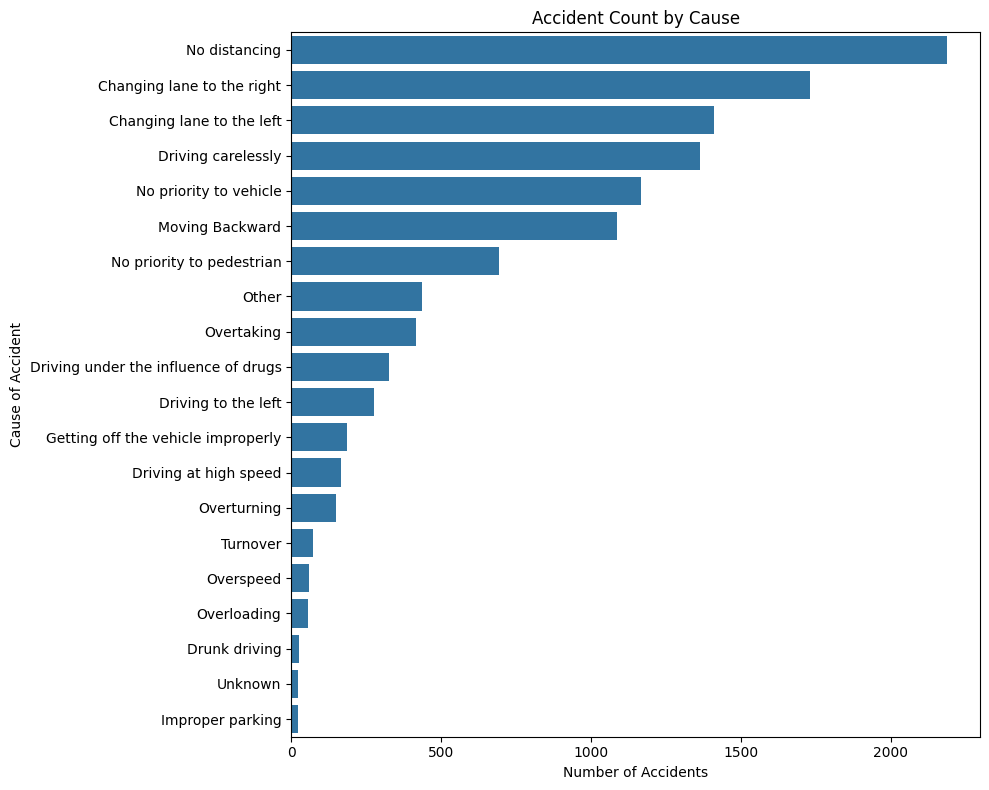

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

order = df['Cause_of_accident'].value_counts().index

plt.figure(figsize=(10, 8))
sns.countplot(data=df, y='Cause_of_accident', order=order)

plt.title('Accident Count by Cause') # title
plt.xlabel('Number of Accidents') # x-axis label
plt.ylabel('Cause of Accident') # y-axis label
plt.tight_layout() # readable labels, no overlap
plt.show()

### 2. What factors are associated with serious and fatal accidents?

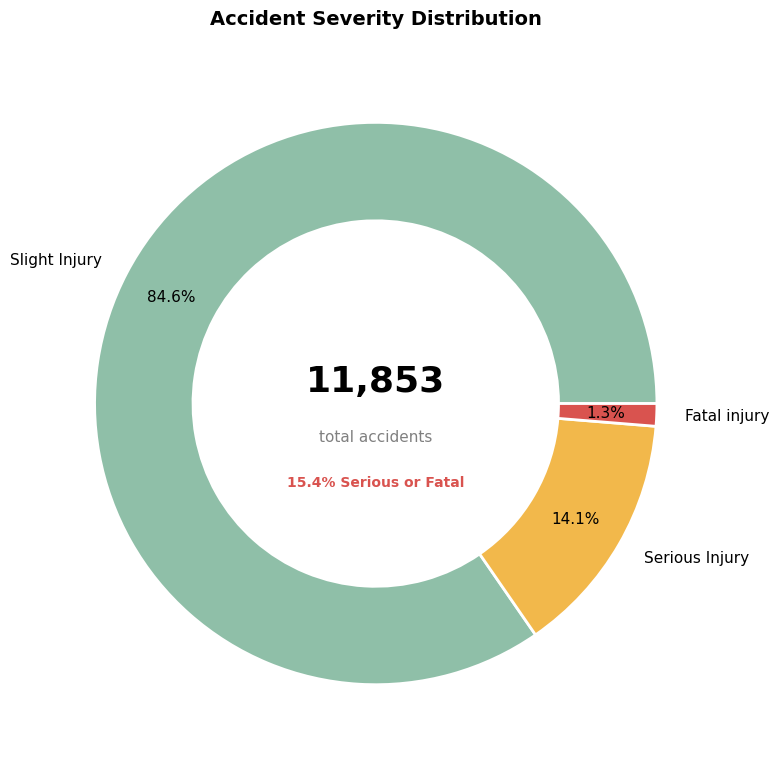

In [34]:
fig, ax = plt.subplots(figsize=(8, 8))
severity_counts = df['Accident_severity'].value_counts()
total = len(df)
severe_pct = (severity_counts['Serious Injury'] + severity_counts['Fatal injury']) / total * 100

colors = ['#8FBFA8', '#F2B84B', '#D9534F']
ax.pie(
    severity_counts.values, labels=severity_counts.index, autopct='%1.1f%%',
    colors=colors, wedgeprops={'width': 0.35, 'edgecolor': 'white', 'linewidth': 2},
    pctdistance=0.82, textprops={'fontsize': 11}
)

ax.text(0, 0.08, f'{total:,}', ha='center', va='center', fontsize=26, fontweight='bold')
ax.text(0, -0.12, 'total accidents', ha='center', va='center', fontsize=11, color='gray')
ax.text(0, -0.28, f'{severe_pct:.1f}% Serious or Fatal', ha='center', va='center',
        fontsize=10, color='#D9534F', fontweight='bold')

plt.title('Accident Severity Distribution', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

### 3. Does the age of the driver affect accident severity?

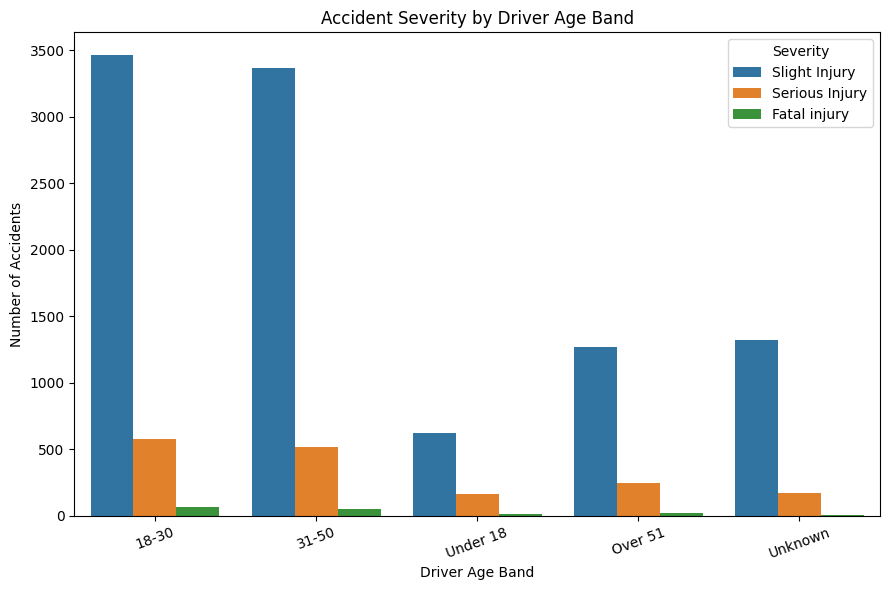

In [35]:
plt.figure(figsize=(9, 6))
sns.countplot(data=df, x='Age_band_of_driver', hue='Accident_severity')

plt.title('Accident Severity by Driver Age Band')
plt.xlabel('Driver Age Band')
plt.ylabel('Number of Accidents')
plt.xticks(rotation=20)
plt.legend(title='Severity')
plt.tight_layout()
plt.show()

### 4. Does weather affect how serious an accident is?

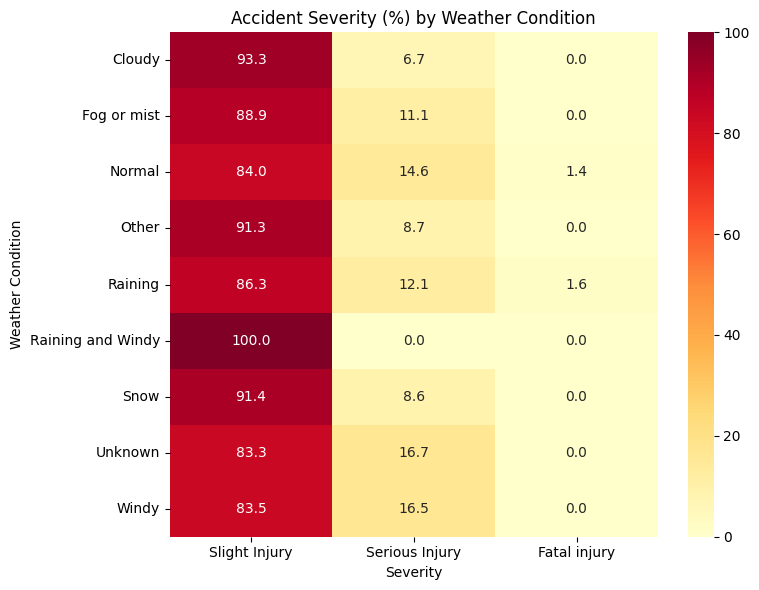

In [36]:
ct_weather = pd.crosstab(df['Weather_conditions'], df['Accident_severity'], normalize='index') * 100
ct_weather = ct_weather[['Slight Injury', 'Serious Injury', 'Fatal injury']]

plt.figure(figsize=(8, 6))
sns.heatmap(ct_weather, annot=True, fmt='.1f', cmap='YlOrRd')

plt.title('Accident Severity (%) by Weather Condition')
plt.xlabel('Severity')
plt.ylabel('Weather Condition')
plt.tight_layout()
plt.show()

### 5. At what time of day do most accidents happen?

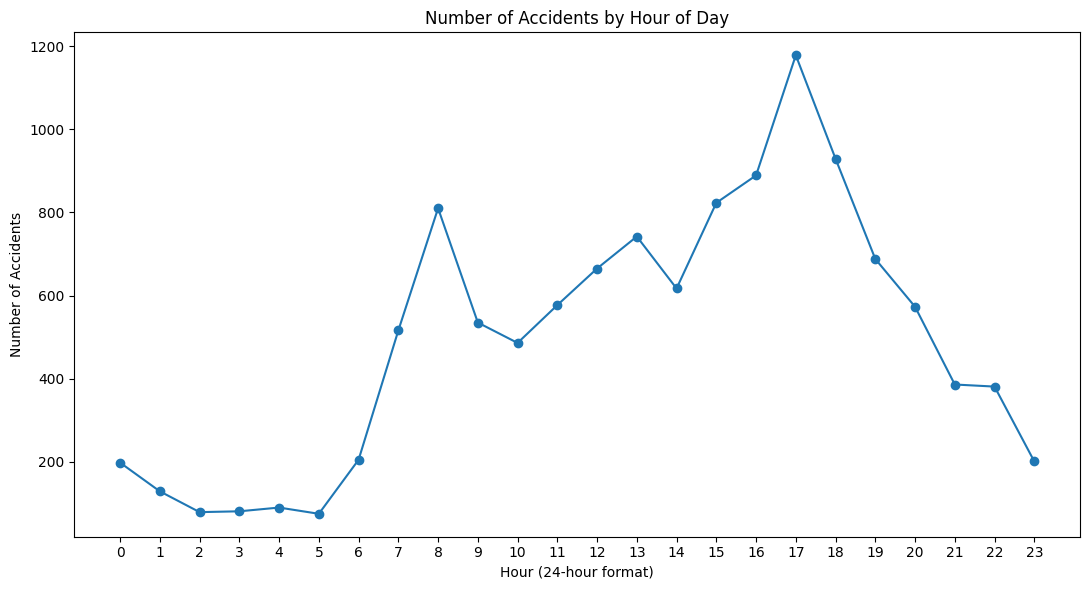

In [37]:
hourly_counts = df['Hour'].value_counts().sort_index()

plt.figure(figsize=(11, 6))
plt.plot(hourly_counts.index, hourly_counts.values, marker='o')

plt.title('Number of Accidents by Hour of Day')
plt.xlabel('Hour (24-hour format)')
plt.ylabel('Number of Accidents')
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

### 6. Does road surface condition (e.g. damaged/distressed roads) affect accident severity?

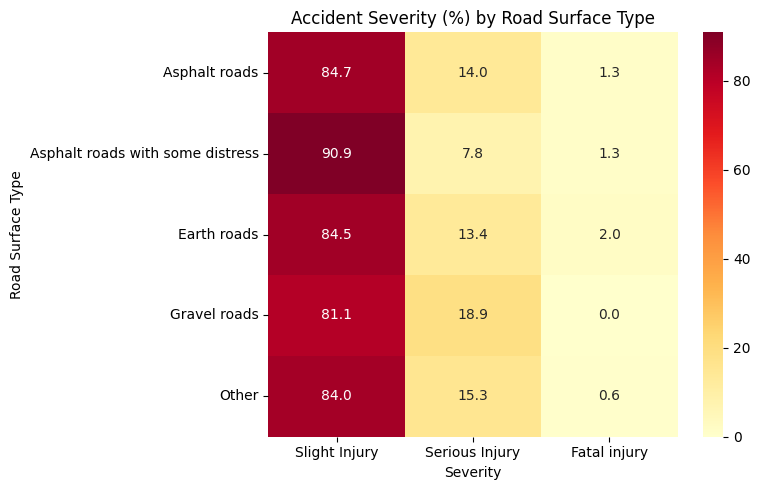

In [38]:
ct_road = pd.crosstab(df['Road_surface_type'], df['Accident_severity'], normalize='index') * 100
ct_road = ct_road[['Slight Injury', 'Serious Injury', 'Fatal injury']]

plt.figure(figsize=(8, 5))
sns.heatmap(ct_road, annot=True, fmt='.1f', cmap='YlOrRd')

plt.title('Accident Severity (%) by Road Surface Type')
plt.xlabel('Severity')
plt.ylabel('Road Surface Type')
plt.tight_layout()
plt.show()

## 6. Select Appropriate Visualizations

**Q1 — Main causes of accidents → Count Plot**
`Cause_of_accident` has many categories, and we wanted to rank them from most common to least common. A count plot (sorted bar chart) makes this comparison clear at a glance — a pie chart would have too many slices to read.

**Q2 — What factors are associated with serious and fatal accidents? → Summary Analysis**
Instead of a new chart, we filtered the data to only Serious/Fatal accidents and compared them against our earlier findings (cause, lighting, age) to see which factors show up most in the worst accidents.

**Q3 — Driver age and severity → Bar Chart**
Same reason as Q2 — both variables are categories, so a bar chart comparing severity across age groups is the clearest way to see differences between groups.

**Q4 — Weather and severity → Heatmap**
Weather has many categories (9 types), and comparing all of them against 3 severity levels means a lot of combinations. A heatmap lets us see every combination at once using color, which would be messy with many small bar charts.

**Q5 — Time of day → Line Chart**
`Hour` is a number that goes in order (0 to 23). A line chart is the standard way to show how something changes across an ordered sequence like time, and it makes the peak hours easy to spot.

**Q6 (Extra) — Road surface and severity → Area Chart (Bad) → Heatmap (Corrected)**
Used specifically to demonstrate a poor chart choice on unordered categories, then corrected with a heatmap that matches the data's real structure — as required for the Bad Visualization and Comparison sections.

---

## 8. Interpretation of Each Visualization

### 1) Question: What are the main causes of road accidents?

- **Visualization:** Count plot of `Cause_of_accident`
- **Reason:** Many categories, so a sorted bar chart shows the top ones clearly.
- **Observation:** "No distancing" is the top cause (2,188 accidents), followed by unsafe lane changes and careless driving.
- **Insight:** Most accidents happen because of driver behavior, not weather or vehicle problems.

---

### 2) Question: What factors are associated with serious and fatal accidents?

- **Visualization:** Summary analysis (filtered Serious/Fatal accidents)
- **Reason:** Instead of a new chart, we looked only at Serious/Fatal accidents to see which factors show up most.
- **Observation:** The same top causes (no distancing, unsafe lane changes, careless driving) also lead to severe accidents, and dark/lit conditions show up more than expected.
- **Insight:** The same factors that cause accidents overall also make them worse — fixing driver behavior helps both.

---

### 3) Question: Does the age of the driver affect accident severity?

- **Visualization:** Bar chart of `Age_band_of_driver` by `Accident_severity`
- **Reason:** Both are categories, so a bar chart compares severity across age groups clearly.
- **Observation:** Under-18 drivers have a higher share of Serious/Fatal accidents than other age groups.
- **Insight:** Younger, less experienced drivers are linked to more severe accidents.

---

### 4) Question: Does weather affect how serious an accident is?

- **Visualization:** Heatmap of `Weather_conditions` vs. `Accident_severity`
- **Reason:** Weather has many categories, so a heatmap shows all combinations with severity using color.
- **Observation:** Rain shows a slightly higher Fatal percentage than other weather conditions, but the difference is small.
- **Insight:** Weather has only a small effect on severity — smaller than driver age.

---

### 5) Question: At what time of day do most accidents happen?

- **Visualization:** Line chart of accident count by `Hour`
- **Reason:** `Hour` is ordered (0–23), so a line chart shows the trend across the day.
- **Observation:** Accidents peak sharply around 5 PM, with a smaller peak around 8 AM, and drop late at night.
- **Insight:** Accidents cluster around commute times — evening rush hour is the highest-risk period.

---

## 9. Find Patterns and Relationships

After making all our charts, we looked back across everything to find the bigger patterns — not just what one chart shows, but what connects across multiple charts.

**Trends:**
Accidents follow a clear daily pattern — they rise in the morning, peak sharply around 5 PM, and drop to their lowest late at night. This matches normal traffic/commute patterns rather than being random.

**Differences between groups:**
Not all driver age groups are equally affected — Under 18 drivers have a higher share of serious/fatal accidents than other age groups, even though they're not the group with the most accidents overall. Similarly, "Darkness - no lighting" accidents are less common than daylight ones, but a bigger share of them turn out serious or fatal.

**Relationships between variables:**
Some variables are connected, and some surprisingly aren't. Light conditions and driver age both relate to how serious an accident becomes. But the number of vehicles involved does *not* strongly relate to the number of casualties — a small 2-vehicle crash can be just as harmful as a bigger one.

**Correlations:**
We checked the numeric relationship between vehicles involved and casualties, and found it was weak (around 0.21). This means you can't predict how many people got hurt just from knowing how many vehicles crashed.

**Distributions:**
Most accidents are small — 1 to 2 vehicles involved, 1 to 2 casualties. Severity itself is very unevenly distributed too: most accidents are Slight Injury, and only a small percentage are Fatal.

**Outliers:**
A small number of accidents (around 700) had a higher number of casualties than usual. We kept these in the data, since they're real, serious accidents, not mistakes.

**Increasing/decreasing patterns:**
Accident counts increase steadily from early morning, peak in the evening, then decrease late at night — a clear rise-then-fall pattern across the day.

**Unusual observations:**
Even though most accidents happen in *normal* weather and *daylight* (simply because most driving happens then), the *proportion* of serious/fatal accidents is actually higher in bad conditions like darkness. This is an easy pattern to miss if you only look at raw counts instead of percentages.

**Similarities and differences:**
Weather conditions showed only a small difference in severity, while light conditions and driver age showed a bigger difference. This tells us some environmental factors matter more than others when it comes to how dangerous an accident becomes.

**Overall (Data → Visualization → Observation → Insight):**
Across all our charts, one central insight stands out: what makes an accident *happen* is often different from what makes an accident *severe*. Frequency is mostly driven by traffic/commute timing and common driver mistakes, while severity is more affected by conditions like poor lighting and driver age. This distinction is the main pattern this analysis uncovered.

---

## 10. Create One Bad Visualization & 11. Compare Two Visualization Techniques

We selected Question 6 (Does road surface condition affect accident severity?) and created an intentionally misleading visualization using an area chart.

### Comparing Heatmap and Area Chart

**Question:** Does road surface type affect accident severity?

**Visualization 1:** Heatmap 
**Visualization 2:** Area Chart

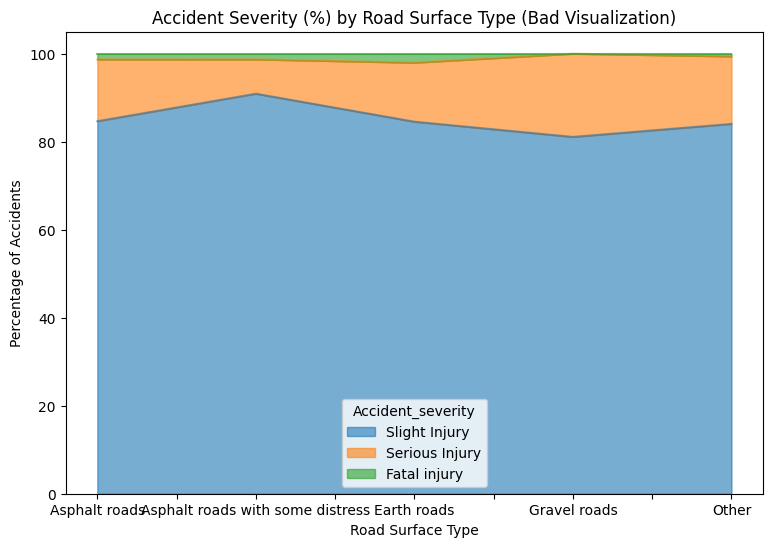

In [39]:
ct_road = pd.crosstab(df['Road_surface_type'], df['Accident_severity'], normalize='index') * 100
ct_road = ct_road[['Slight Injury', 'Serious Injury', 'Fatal injury']]

ct_road.plot(kind='area', figsize=(9, 6), alpha=0.6)
plt.title('Accident Severity (%) by Road Surface Type (Bad Visualization)')
plt.xlabel('Road Surface Type')
plt.ylabel('Percentage of Accidents')
plt.show()

**1. What is wrong with the visualization?**
Road_surface_type has no natural order, but an area chart fills space between points as if it does

**2. Why is it inappropriate or misleading?**
Area charts are for ordered data like time. Using one on unordered categories creates a fake trend that isn't real..

**3. How can it be improved?**
Use a heatmap instead — it treats each road type independently, with no order implied.

**4. Corrected visualization:**

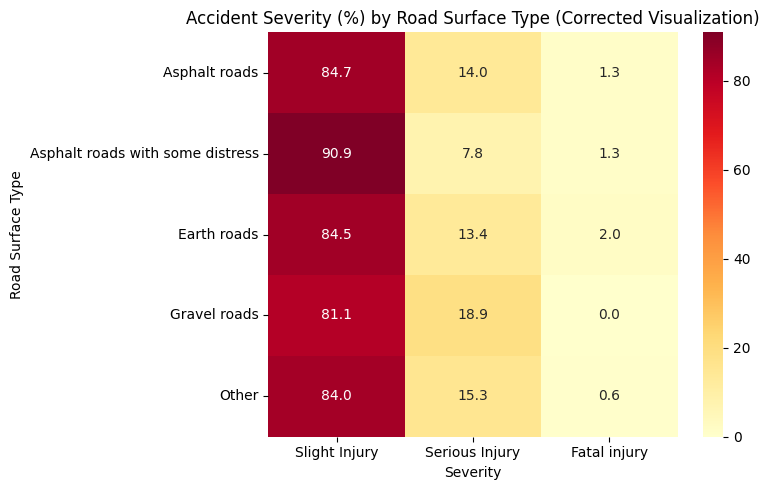

In [40]:
plt.figure(figsize=(8, 5))
sns.heatmap(ct_road, annot=True, fmt='.1f', cmap='YlOrRd')

plt.title('Accident Severity (%) by Road Surface Type (Corrected Visualization)')
plt.xlabel('Severity')
plt.ylabel('Road Surface Type')
plt.tight_layout()
plt.show()

1. Comparing the Area Chart and the Heatmap
2. Question: Does road surface condition affect accident severity?
3. Which communicates better: The heatmap.
4. Why: Road_surface_type has no natural order, so the area chart's filled lines create a fake trend between road types. The heatmap treats each road type as its own independent value, which matches the real data.
5. Easier to understand: The heatmap — each cell can be read on its own using color, without implying any order. The area chart actually makes it harder to tell where one category ends and another begins.
6. Recommendation: Heatmap — it's the only one of the two that fits this kind of category data correctly.

---

## 12. the Most Important Findings

1. Driver behavior causes most accidents — not distancing, unsafe lane changes, careless driving.
2. The same behaviors also make accidents worse — they show up most in Serious/Fatal cases too.
3. Younger drivers have worse accidents — Under-18 drivers show more Serious/Fatal outcomes.
4. Accidents peak at rush hour — highest around 5 PM, lowest late at night.
5. Weather and road damage matter less — both have only a small effect on severity, less than driver age.

---



## 13. Final Conclusion

- We studied over 12,000 road accidents to find their causes and what makes them worse. Driver behavior — not keeping distance and unsafe lane changes — causes most accidents and also leads to the worst ones. Younger drivers face more serious accidents, and most accidents happen during evening rush hour. Weather and road damage had little effect, much less than driver age. The charts helped us find clear patterns and answer our question.

---

## 14.	Limitations
- Very few accidents are Fatal (1.3%), so anything we found about Fatal accidents might not be very reliable.
- Some data was missing (up to 36%), and we filled it with "Unknown",this may have hidden some patterns.

---


## 15.	References
- Dataset: "Road Traffic Accidents" — Kaggle. https://www.kaggle.com/datasets/saurabhshahane/road-traffic-accidents
- Tools used: Python (pandas, matplotlib, seaborn) for data cleaning and visualization.
- Source code: https://github.com/ikundanpatil/Road-Traffic-Accidents.git — contains the full notebooks for data cleaning, analysis, and visualization.

---
